# Transformer Summarizer — Hyperparameter Search (v2)

Four stages, one shared budget, one learning rate. What v2 changes against the
first run (whose logs are kept in `reports/10_summarizer_search_v1.md`):

* **One learning rate for the whole architecture stage.** v1 baked a different
  rate into every grid entry (2e-3 / 1.25e-3 / 1e-3 by width) and then found
  2e-4 to be optimal — so the shapes were ranked at a rate 5-10x too high, and
  two trials diverged to NaN outright. Shape is now compared at 2e-4, and the
  rate is searched afterwards, on the winner.
* **Encoder and decoder depth are separate.** v1's `num_layers` fed both stacks,
  so a deep encoder over a shallow decoder — the shape summarization usually
  wants, and the one the failure cases point at — could not be expressed.
* **A noise floor is measured first.** In v1 the spread across all fifteen
  architectures was 0.129 while two seeds of one architecture differed by 0.093.
  Stage A trains one configuration three times so later stages can be read
  against a known error bar instead of being trusted digit by digit.
* **No seed axis in the grid, and no 30%-then-70% shortlist.** v1's 30% stage
  ranked its eventual winner last of six finalists, so its ranking carried no
  signal worth paying for. Every stage now runs at the same 50%, which is also
  what makes the stages comparable to each other.
* **Diverged trials are pruned, not scored.** A NaN run used to return the best
  value it reached beforehand and be ranked as if it were healthy.

Stage budget: 3 + 8 + 10 + 15 = 36 trials, against 111 in v1.

## Setup

In [57]:
%load_ext autoreload
%autoreload 2

In [58]:
import math
import os
from collections.abc import Callable
from dataclasses import asdict, dataclass, replace
from pathlib import Path

import matplotlib.pyplot as plt
import optuna
import pandas as pd
import sentencepiece as spm
import torch
from colorama import Fore, Style
from datasets import load_dataset
from dotenv import load_dotenv
from torch import nn
from torch.utils.data import DataLoader, Dataset

from dl_roadmap.chapters.summarization import (
    SummarizationDataset,
    Summarizer,
    prepare_gazeta,
)
from dl_roadmap.chapters.summarization.dataset import make_collate_fn
from dl_roadmap.engine import (
    CombinedEarlyStopping,
    EarlyStopping,
    EpochWarmupScheduler,
    GapThresholdEarlyStopping,
    GeneratedRougeScore,
    MetricEarlyStopping,
    MetricsManager,
    OptimizationConfig,
    OptimizationEngine,
    TeacherForcingTrainer,
    TrainingConfig,
    make_token_loss,
)
from dl_roadmap.utils import (
    LoggerConfig,
    notify_model_trained,
    seed_everything,
    setup_logger,
)
from dl_roadmap.visualization import plot_training_history_on_ax

In [59]:
%matplotlib inline

pd.set_option("display.width", 150)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", None)

load_dotenv()
seed_everything()
setup_logger(LoggerConfig(log_level="WARNING"))

In [60]:
PROJECT_NAME = "10_summarizer"
SEED = 42

DATA_DIR = Path("../data")
MODEL_DIR = Path("../models") / PROJECT_NAME
REPORT_DIR = Path("../reports")

RAW_DATA_DIR = DATA_DIR / "raw" / PROJECT_NAME
PROCESSED_DATA_DIR = DATA_DIR / "processed" / PROJECT_NAME
TOKENIZER_DIR = MODEL_DIR / "tokenizer"
OPTUNA_DIR = MODEL_DIR / "optuna"
FIG_DIR = REPORT_DIR / "figures" / "10_summarizer_tuning"

DIRECTORIES = (
    RAW_DATA_DIR,
    PROCESSED_DATA_DIR,
    MODEL_DIR,
    TOKENIZER_DIR,
    OPTUNA_DIR,
    FIG_DIR,
)

for directory in DIRECTORIES:
    directory.mkdir(parents=True, exist_ok=True)

## Dataset

In [61]:
dataset = load_dataset("IlyaGusev/gazeta", cache_dir=RAW_DATA_DIR)

train_df = dataset["train"].shuffle(seed=SEED).to_pandas()
val_df = dataset["validation"].to_pandas()

In [62]:
train_df = prepare_gazeta(train_df, cache_file=PROCESSED_DATA_DIR / "train_df.csv")
val_df = prepare_gazeta(val_df, cache_file=PROCESSED_DATA_DIR / "val_df.csv")

### SentencePiece

In [63]:
force_tokenizer_train = False

if force_tokenizer_train or not (TOKENIZER_DIR / "sp.model").is_file():
    data_path = PROCESSED_DATA_DIR / "data.txt"
    data_path.write_text("\n".join(train_df["text"]), encoding="utf-8")

    spm.SentencePieceTrainer.train(
        input=str(data_path),
        model_prefix=str(TOKENIZER_DIR / "sp"),
        vocab_size=16000,
        model_type="unigram",
        character_coverage=1.0,
        byte_fallback=True,
        max_sentence_length=16384,
        num_threads=os.cpu_count() or 4,
        pad_id=3,
        unk_id=2,
        bos_id=0,
        eos_id=1,
        pad_piece="<PAD>",
        unk_piece="<UNK>",
        bos_piece="<BOS>",
        eos_piece="<EOS>",
    )

sp = spm.SentencePieceProcessor(model_file=str(TOKENIZER_DIR / "sp.model"))

### Collation

In [64]:
pad_id = sp.pad_id()
collate_fn = make_collate_fn(pad_id)

## Tools

In [65]:
loss = make_token_loss(pad_id, label_smoothing=0.1)

In [66]:
ROUGE_EXAMPLES = 64


def make_rouge(
    model: Summarizer, max_examples: int | None = None
) -> GeneratedRougeScore:
    """Build free-running ROUGE for the Optuna objective.

    Args:
        model: Model whose autoregressive ``generate`` method is scored.
        max_examples: Score this many fixed validation examples per epoch;
            None scores the whole validation pass.

    Returns:
        Free-running rouge1/rouge2/rougeL F-measure and their mean.
    """
    return GeneratedRougeScore(
        generate=model.generate,
        decode=sp.decode,
        pad_id=pad_id,
        max_examples=max_examples,
        generation_kwargs={
            # Greedy decoding keeps tuning affordable. Use the same
            # settings for every trial; re-rank finalists with beam search.
            "max_length": 100,
            "min_length": 35,
            "beam_width": 1,
            "length_penalty_alpha": 1.0,
            "repetition_penalty": 1.2,
            "no_repeat_ngram_size": 3,
        },
    )


def loss_at_best(
    trainer: TeacherForcingTrainer, rouge_early: MetricEarlyStopping
) -> float | None:
    """Returns the validation loss of the epoch early stopping calls best.

    Args:
        trainer: The finished trainer, whose history holds the per-epoch values.
        rouge_early: The ROUGE strategy that scored the run.

    Returns:
        The validation loss at the best epoch, or None if no epoch was scored.
    """
    losses = trainer.history["val_loss"]

    if rouge_early.best_epoch is None or not losses:
        return None

    return losses[rouge_early.best_epoch - 1]

## Search infrastructure

In [67]:
@dataclass(frozen=True)
class HParams:
    """Hyperparameters of a single trial."""

    model_dim: int = 256
    num_heads: int = 4
    num_encoder_layers: int = 6
    num_decoder_layers: int = 3
    ffn_ratio: int = 4
    dropout: float = 0.1
    lr: float = 2e-4
    weight_decay: float = 1e-2
    use_weight_tying: bool = True
    seed: int = 42

    @property
    def ffn_dim(self) -> int:
        """Returns the FFN hidden size implied by ``ffn_ratio``."""
        return self.ffn_ratio * self.model_dim

    @property
    def num_params(self) -> int:
        """Returns the parameter count this configuration implies."""
        dim, ratio = self.model_dim, self.ffn_ratio

        encoder = self.num_encoder_layers * (4 * dim + 2 * ratio * dim) * dim
        decoder = self.num_decoder_layers * (8 * dim + 2 * ratio * dim) * dim
        embedding = sp.get_piece_size() * dim * (1 if self.use_weight_tying else 2)

        return encoder + decoder + embedding

    @property
    def is_valid(self) -> bool:
        """Returns whether the head count evenly divides the model dim."""
        return self.model_dim % self.num_heads == 0


BASE = HParams()

In [68]:
@dataclass(frozen=True)
class Stage:
    """Budget and stopping rules of one search stage."""

    name: str
    epochs: int
    n_trials: int
    fraction: float = 0.5
    batch_size: int = 8
    effective_batch_size: int = 32
    amp: str = "auto"
    es_patience: int = 5
    es_min_delta: float = 1e-4
    warmup_epochs: float = 1.0
    gap_threshold: float | None = 0.8
    use_scheduler: bool = True
    show_progress: bool = False
    save_models: bool = False

    @property
    def accumulation_steps(self) -> int:
        """Returns the micro-batches accumulated per optimizer step."""
        return max(self.effective_batch_size // self.batch_size, 1)

In [69]:
VAL_FRACTION = 0.5

_dataset_cache: dict[str, Dataset] = {}


def get_train_dataset(fraction: float) -> Dataset:
    """Returns the cached train subset for a given data fraction.

    Args:
        fraction: Share of the full train frame to keep.

    Returns:
        The train dataset.
    """
    key = f"train:{fraction}"

    if key not in _dataset_cache:
        _dataset_cache[key] = SummarizationDataset(
            train_df.sample(frac=fraction, random_state=SEED), sp
        )

    return _dataset_cache[key]


def get_val_dataset() -> Dataset:
    """Returns the one validation subset every stage is scored on.

    Fixed at `VAL_FRACTION` regardless of a stage's train fraction, so the
    values of two stages are measured against the same yardstick.

    Returns:
        The validation dataset.
    """
    key = f"val:{VAL_FRACTION}"

    if key not in _dataset_cache:
        _dataset_cache[key] = SummarizationDataset(
            val_df.sample(frac=VAL_FRACTION, random_state=SEED), sp
        )

    return _dataset_cache[key]


def make_loaders(stage: Stage, seed: int) -> tuple[DataLoader, DataLoader]:
    """Builds the train/val dataloaders for one trial.

    The train shuffle gets its own generator rather than drawing from the
    global RNG: an unseeded `DataLoader` reseeds itself per epoch from
    whatever is left of the global stream, and `build_model` consumes that
    stream in proportion to the parameter count. Two trials sharing a seed
    would otherwise see different batch orders for different architectures.

    Args:
        stage: The stage whose data fraction and batch size to use.
        seed: Seed for the train shuffle.

    Returns:
        A tuple of the train and validation dataloaders. The datasets come
        from `_dataset_cache`, so rebuilding the loaders per trial is free.
    """
    train_dataset = get_train_dataset(stage.fraction)
    val_dataset = get_val_dataset()

    shuffle_generator = torch.Generator()
    shuffle_generator.manual_seed(seed)

    train_loader = DataLoader(
        train_dataset,
        batch_size=stage.batch_size,
        shuffle=True,
        generator=shuffle_generator,
        collate_fn=collate_fn,
        drop_last=True,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=stage.batch_size,
        shuffle=False,
        collate_fn=collate_fn,
        drop_last=False,
    )

    return train_loader, val_loader

In [70]:
def build_model(hp: HParams) -> Summarizer:
    """Instantiates a `Summarizer` from trial hyperparameters.

    Args:
        hp: The trial's hyperparameters.

    Returns:
        The untrained model.
    """
    return Summarizer(
        sp,
        model_dim=hp.model_dim,
        num_heads=hp.num_heads,
        num_encoder_layers=hp.num_encoder_layers,
        num_decoder_layers=hp.num_decoder_layers,
        ffn_dim=hp.ffn_dim,
        dropout=hp.dropout,
        use_weight_tying=hp.use_weight_tying,
    )


def build_optimizer(model: nn.Module, hp: HParams) -> torch.optim.Optimizer:
    """Builds AdamW with weight decay applied to weight matrices only.

    Args:
        model: The model whose parameters to optimize.
        hp: The trial's hyperparameters.

    Returns:
        The configured optimizer.
    """
    decay, no_decay = [], []
    for name, param in model.named_parameters():
        target = no_decay if name.endswith("bias") or "norm" in name else decay
        target.append(param)

    return torch.optim.AdamW(
        [
            {"params": decay, "weight_decay": hp.weight_decay},
            {"params": no_decay, "weight_decay": 0.0},
        ],
        lr=hp.lr,
    )


def build_scheduler(
    optimizer: torch.optim.Optimizer, stage: Stage
) -> EpochWarmupScheduler:
    """Builds the warmup ramp and the plateau decay that takes over from it.

    Args:
        optimizer: The optimizer to schedule.
        stage: The stage whose warmup length to apply, and whose
            `use_scheduler` decides whether anything follows the ramp.

    Returns:
        The configured scheduler.
    """
    plateau = (
        torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="min",
            factor=0.3,
            patience=3,
            min_lr=3e-5,
            threshold=0.01,
            threshold_mode="abs",
            cooldown=1,
        )
        if stage.use_scheduler
        else None
    )

    return EpochWarmupScheduler(
        optimizer,
        warmup_epochs=stage.warmup_epochs,
        scheduler=plateau,
    )


def build_early_stopping(
    stage: Stage,
) -> tuple[MetricEarlyStopping, EarlyStopping]:
    """Builds the stage's early stopping strategy.

    Args:
        stage: The stage whose patience and gap threshold to apply.

    Returns:
        A tuple of the mean-ROUGE strategy (whose ``best_score`` is the
        objective value) and the strategy handed to the trainer.
    """
    rouge_early = MetricEarlyStopping(
        "val_rouge_mean",
        patience=stage.es_patience,
        min_delta=stage.es_min_delta,
    )

    if stage.gap_threshold is None:
        return rouge_early, rouge_early

    combined = CombinedEarlyStopping(
        [
            rouge_early,
            GapThresholdEarlyStopping(
                patience=stage.es_patience, threshold=stage.gap_threshold
            ),
        ],
        combine="any",
    )

    return rouge_early, combined

In [71]:
def make_report_callback(
    trial: optuna.Trial, rouge: GeneratedRougeScore
) -> Callable[[int, float, float | None], None]:
    """Builds an epoch callback reporting mean ROUGE to Optuna and pruning.

    Args:
        trial: The running trial.
        rouge: The metric the trainer runs. Callbacks fire after the
            validation pass, so it still holds that pass's scores.

    Returns:
        A trainer callback of the form ``(epoch, train_loss, val_loss)``.
    """
    best_so_far = -math.inf

    def report_callback(epoch: int, train_loss: float, val_loss: float | None) -> None:
        nonlocal best_so_far

        if not math.isfinite(train_loss):
            raise optuna.TrialPruned(
                f"diverged: train_loss={train_loss} at epoch {epoch}"
            )

        if val_loss is not None and not math.isfinite(val_loss):
            raise optuna.TrialPruned(f"diverged: val_loss={val_loss} at epoch {epoch}")

        score = rouge.compute().get("mean")

        if score is None:
            return

        best_so_far = max(best_so_far, score)
        trial.report(best_so_far, epoch)

        if trial.should_prune():
            raise optuna.TrialPruned

    return report_callback


def make_objective(
    stage: Stage, suggest: Callable[[optuna.Trial], HParams]
) -> Callable[[optuna.Trial], float]:
    """Builds the Optuna objective for one stage.

    Args:
        stage: Budget and stopping rules of the stage.
        suggest: Maps a trial to the hyperparameters to train with.

    Returns:
        The objective function, maximizing the mean ROUGE.
    """

    def objective(trial: optuna.Trial) -> float:
        hp = suggest(trial)

        if not hp.is_valid:
            raise optuna.TrialPruned

        seed_everything(hp.seed)
        train_loader, val_loader = make_loaders(stage, hp.seed)

        model = build_model(hp)
        optimizer = build_optimizer(model, hp)
        scheduler = build_scheduler(optimizer, stage)
        rouge_early, early_stopping = build_early_stopping(stage)
        rouge = make_rouge(model, max_examples=ROUGE_EXAMPLES)

        trainer = TeacherForcingTrainer(
            model=model,
            loss_fn=loss.loss_fn,
            config=TrainingConfig(
                epochs=stage.epochs,
                show_progress=stage.show_progress,
            ),
            optimization=OptimizationEngine(
                optimizer,
                scheduler,
                OptimizationConfig(
                    accumulation_steps=stage.accumulation_steps,
                    grad_normalizer=loss.grad_normalizer,
                    grad_clip_norm=1.0,
                    amp=stage.amp,
                ),
            ),
            metrics=MetricsManager(
                loss_tracker=loss.loss_tracker,
                metrics={"rouge": rouge},
            ),
            callbacks=[make_report_callback(trial, rouge)],
            early_stopping=early_stopping,
        )

        try:
            trainer.fit(train_loader, val_loader)

            if stage.save_models:
                trainer.save(MODEL_DIR / stage.name / f"trial_{trial.number:03d}.pt")

            if rouge_early.best_score is None:
                raise optuna.TrialPruned("no epoch scored a rouge value")

            trial.set_user_attr("best_epoch", rouge_early.best_epoch)
            trial.set_user_attr("history", trainer.history)
            trial.set_user_attr("val_loss", loss_at_best(trainer, rouge_early))

            return rouge_early.best_score
        except torch.cuda.OutOfMemoryError as err:
            raise optuna.TrialPruned from err
        finally:
            del model, optimizer, trainer
            torch.cuda.empty_cache()

    return objective

In [72]:
STORAGE = f"sqlite:///{OPTUNA_DIR}/optuna.db"


def run_stage(
    stage: Stage,
    suggest: Callable[[optuna.Trial], HParams],
    sampler: optuna.samplers.BaseSampler,
    pruner: optuna.pruners.BasePruner | None = None,
) -> optuna.Study:
    """Creates (or resumes) the stage's study and runs the search.

    Args:
        stage: Budget and stopping rules of the stage.
        suggest: Maps a trial to the hyperparameters to train with.
        sampler: Optuna sampler for this stage.
        pruner: Optuna pruner; defaults to no pruning.

    Returns:
        The finished study.
    """
    study = optuna.create_study(
        study_name=stage.name,
        storage=STORAGE,
        direction="maximize",
        sampler=sampler,
        pruner=pruner or optuna.pruners.NopPruner(),
        load_if_exists=True,
    )

    study.optimize(make_objective(stage, suggest), n_trials=stage.n_trials)

    print(
        f"\n{Fore.GREEN}[{stage.name}] best value:{Style.RESET_ALL} "
        f"{study.best_value:.4f}"
    )
    print(
        f"{Fore.CYAN}[{stage.name}] best params:{Style.RESET_ALL} {study.best_params}"
    )

    notify_model_trained(
        f"Summarizer / {stage.name}",
        {"best_rouge": study.best_value, **study.best_params},
    )

    return study

## Stage A

In [17]:
A_ARCH_GRID = {
    # model_dim = 256
    "A0_d256_e6d3": HParams(
        model_dim=256,
        num_heads=4,
        num_encoder_layers=6,
        num_decoder_layers=3,
        ffn_ratio=4,
    ),
    "A1_d256_e4d4": HParams(
        model_dim=256,
        num_heads=4,
        num_encoder_layers=4,
        num_decoder_layers=4,
        ffn_ratio=4,
    ),
    "A2_d256_e8d2": HParams(
        model_dim=256,
        num_heads=4,
        num_encoder_layers=8,
        num_decoder_layers=2,
        ffn_ratio=4,
    ),
    "A3_d256_e10d1": HParams(
        model_dim=256,
        num_heads=4,
        num_encoder_layers=10,
        num_decoder_layers=1,
        ffn_ratio=4,
    ),
    "A4_d256_e3d6": HParams(
        model_dim=256,
        num_heads=4,
        num_encoder_layers=3,
        num_decoder_layers=6,
        ffn_ratio=4,
    ),
    # model_dim = 384
    "B0_d384_e6d3": HParams(
        model_dim=384,
        num_heads=6,
        num_encoder_layers=6,
        num_decoder_layers=3,
        ffn_ratio=4,
    ),
    "B1_d384_e4d4": HParams(
        model_dim=384,
        num_heads=6,
        num_encoder_layers=4,
        num_decoder_layers=4,
        ffn_ratio=4,
    ),
    "B2_d384_e8d2": HParams(
        model_dim=384,
        num_heads=6,
        num_encoder_layers=8,
        num_decoder_layers=2,
        ffn_ratio=4,
    ),
    "B3_d384_e10d1": HParams(
        model_dim=384,
        num_heads=6,
        num_encoder_layers=10,
        num_decoder_layers=1,
        ffn_ratio=4,
    ),
    "B4_d384_e3d6": HParams(
        model_dim=384,
        num_heads=6,
        num_encoder_layers=3,
        num_decoder_layers=6,
        ffn_ratio=4,
    ),
    # model_dim = 512
    "C0_d512_e6d3": HParams(
        model_dim=512,
        num_heads=8,
        num_encoder_layers=6,
        num_decoder_layers=3,
        ffn_ratio=4,
    ),
    "C1_d512_e4d4": HParams(
        model_dim=512,
        num_heads=8,
        num_encoder_layers=4,
        num_decoder_layers=4,
        ffn_ratio=4,
    ),
    "C2_d512_e8d2": HParams(
        model_dim=512,
        num_heads=8,
        num_encoder_layers=8,
        num_decoder_layers=2,
        ffn_ratio=4,
    ),
    "C3_d512_e10d1": HParams(
        model_dim=512,
        num_heads=8,
        num_encoder_layers=10,
        num_decoder_layers=1,
        ffn_ratio=4,
    ),
    "C4_d512_e3d6": HParams(
        model_dim=512,
        num_heads=8,
        num_encoder_layers=3,
        num_decoder_layers=6,
        ffn_ratio=4,
    ),
    # model_dim = 768
    "D0_d768_e6d3": HParams(
        model_dim=768,
        num_heads=12,
        num_encoder_layers=6,
        num_decoder_layers=3,
        ffn_ratio=4,
    ),
    "D1_d768_e4d4": HParams(
        model_dim=768,
        num_heads=12,
        num_encoder_layers=4,
        num_decoder_layers=4,
        ffn_ratio=4,
    ),
    "D2_d768_e8d2": HParams(
        model_dim=768,
        num_heads=12,
        num_encoder_layers=8,
        num_decoder_layers=2,
        ffn_ratio=4,
    ),
    "D3_d768_e10d1": HParams(
        model_dim=768,
        num_heads=12,
        num_encoder_layers=10,
        num_decoder_layers=1,
        ffn_ratio=4,
    ),
    "D4_d768_e3d6": HParams(
        model_dim=768,
        num_heads=12,
        num_encoder_layers=3,
        num_decoder_layers=6,
        ffn_ratio=4,
    ),
}

assert all(hp.is_valid for hp in A_ARCH_GRID.values()), "head count must divide dim"


pd.DataFrame(
    [
        {
            "key": key,
            **asdict(hp),
            "params": f"{hp.num_params / 1e6:.1f}M",
        }
        for key, hp in A_ARCH_GRID.items()
    ]
)

,key,model_dim,num_heads,num_encoder_layers,num_decoder_layers,ffn_ratio,dropout,lr,weight_decay,use_weight_tying,seed,params
0,A0_d256_e6d3,256,4,6,3,4,0.1,0.0002,0.01,True,42,12.0M
1,A1_d256_e4d4,256,4,4,4,4,0.1,0.0002,0.01,True,42,11.4M
2,A2_d256_e8d2,256,4,8,2,4,0.1,0.0002,0.01,True,42,12.5M
3,A3_d256_e10d1,256,4,10,1,4,0.1,0.0002,0.01,True,42,13.0M
4,A4_d256_e3d6,256,4,3,6,4,0.1,0.0002,0.01,True,42,12.7M
5,B0_d384_e6d3,384,6,6,3,4,0.1,0.0002,0.01,True,42,23.8M
6,B1_d384_e4d4,384,6,4,4,4,0.1,0.0002,0.01,True,42,22.7M
7,B2_d384_e8d2,384,6,8,2,4,0.1,0.0002,0.01,True,42,25.0M
8,B3_d384_e10d1,384,6,10,1,4,0.1,0.0002,0.01,True,42,26.2M
9,B4_d384_e3d6,384,6,3,6,4,0.1,0.0002,0.01,True,42,25.6M


In [18]:
def suggest_arch(trial: optuna.Trial) -> HParams:
    """Picks one architecture from the grid; every other field is fixed."""
    return A_ARCH_GRID[trial.suggest_categorical("arch_key", list(A_ARCH_GRID))]


study_arch = run_stage(
    Stage(
        name="study_arch_30",
        epochs=50,
        n_trials=len(A_ARCH_GRID),
        fraction=0.3,
        batch_size=8,
        effective_batch_size=32,
        amp="auto",
        es_patience=7,
        es_min_delta=1e-3,
        warmup_epochs=1.0,
        gap_threshold=None,
        use_scheduler=True,
        show_progress=True,
        save_models=False,
    ),
    suggest_arch,
    sampler=optuna.samplers.GridSampler({"arch_key": list(A_ARCH_GRID)}),
    pruner=optuna.pruners.HyperbandPruner(
        min_resource=5, max_resource=50, reduction_factor=3
    ),
)

[I 2026-08-22 23:17:00,594] A new study created in RDB with name: study_arch_30
epoch 26/50:  52%[==========          ] 58812/113100 :: eta=2:19:09, status=early stopped, train_loss=3.744, val_loss=5.871, val_rouge_mean=0.1543, val_rouge_rouge1=0.2373, val_rouge_rouge2=0.03483, val_rouge_rougeL=0.1908
[I 2026-08-23 01:47:55,719] Trial 0 finished with value: 0.15695969015359879 and parameters: {'arch_key': 'D3_d768_e10d1'}. Best is trial 0 with value: 0.15695969015359879.
epoch 31/50:  62%[============        ] 70122/113100 :: eta=28:25, status=early stopped, train_loss=3.989, val_loss=5.34, val_rouge_mean=0.1816, val_rouge_rouge1=0.2726, val_rouge_rouge2=0.05196, val_rouge_rougeL=0.2203
[I 2026-08-23 02:34:18,239] Trial 1 finished with value: 0.1818931313852469 and parameters: {'arch_key': 'A1_d256_e4d4'}. Best is trial 1 with value: 0.1818931313852469.
epoch 14/50:  28%[=====>              ] 31668/113100 :: eta=1:47:41, status=early stopped, train_loss=2.185, val_loss=5.736, val_rouge


[study_arch_30] best value: 0.1882
[study_arch_30] best params: {'arch_key': 'C1_d512_e4d4'}


In [20]:
study_arch.trials

[FrozenTrial(number=0, state=<TrialState.COMPLETE: 1>, values=[0.15695969015359879], datetime_start=datetime.datetime(2026, 8, 22, 23, 17, 9, 486903), datetime_complete=datetime.datetime(2026, 8, 23, 1, 47, 55, 707511), params={'arch_key': 'D3_d768_e10d1'}, user_attrs={'best_epoch': 19, 'history': {'train_loss': [9.1149365917232, 7.027044719540321, 6.464411752741848, 6.081723254315176, 5.789255982778674, 5.551866149710607, 5.345000155786926, 5.163396232329368, 5.0000926786835125, 4.84442271156306, 4.700485049853727, 4.56562636404866, 4.439097050169025, 4.198916027355009, 4.132854311499244, 4.082186748507277, 4.034982071954059, 3.9899809566044273, 3.9135073025139313, 3.8860335762285825, 3.8617030396407688, 3.8376146288696518, 3.8132867872970775, 3.7907495032758036, 3.767582054506551, 3.7440982387510298], 'val_loss': [7.4134571177744455, 6.729188474039041, 6.363280589531429, 6.111979909481139, 5.937037099321994, 5.822125375979135, 5.740568288309807, 5.6890820682444065, 5.639447908217025,

In [ ]:
pd.DataFrame(
    [
        {
            "state": trial.state.name,
            "value": trial.value,
            "best_epoch": trial.user_attrs.get("best_epoch"),
            **trial.params,
        }
        for trial in study_arch.trials
    ]
).sort_values("value", ascending=False)

,state,value,best_epoch,arch_key
15,COMPLETE,0.188215,14.0,C1_d512_e4d4
4,COMPLETE,0.187691,16.0,C0_d512_e6d3
10,COMPLETE,0.186932,17.0,B0_d384_e6d3
11,COMPLETE,0.186837,13.0,C4_d512_e3d6
2,COMPLETE,0.184947,7.0,D4_d768_e3d6
12,COMPLETE,0.184696,15.0,B4_d384_e3d6
17,COMPLETE,0.183984,27.0,A0_d256_e6d3
8,COMPLETE,0.183037,16.0,A4_d256_e3d6
1,COMPLETE,0.181893,24.0,A1_d256_e4d4
14,PRUNED,0.181521,NaN,D1_d768_e4d4


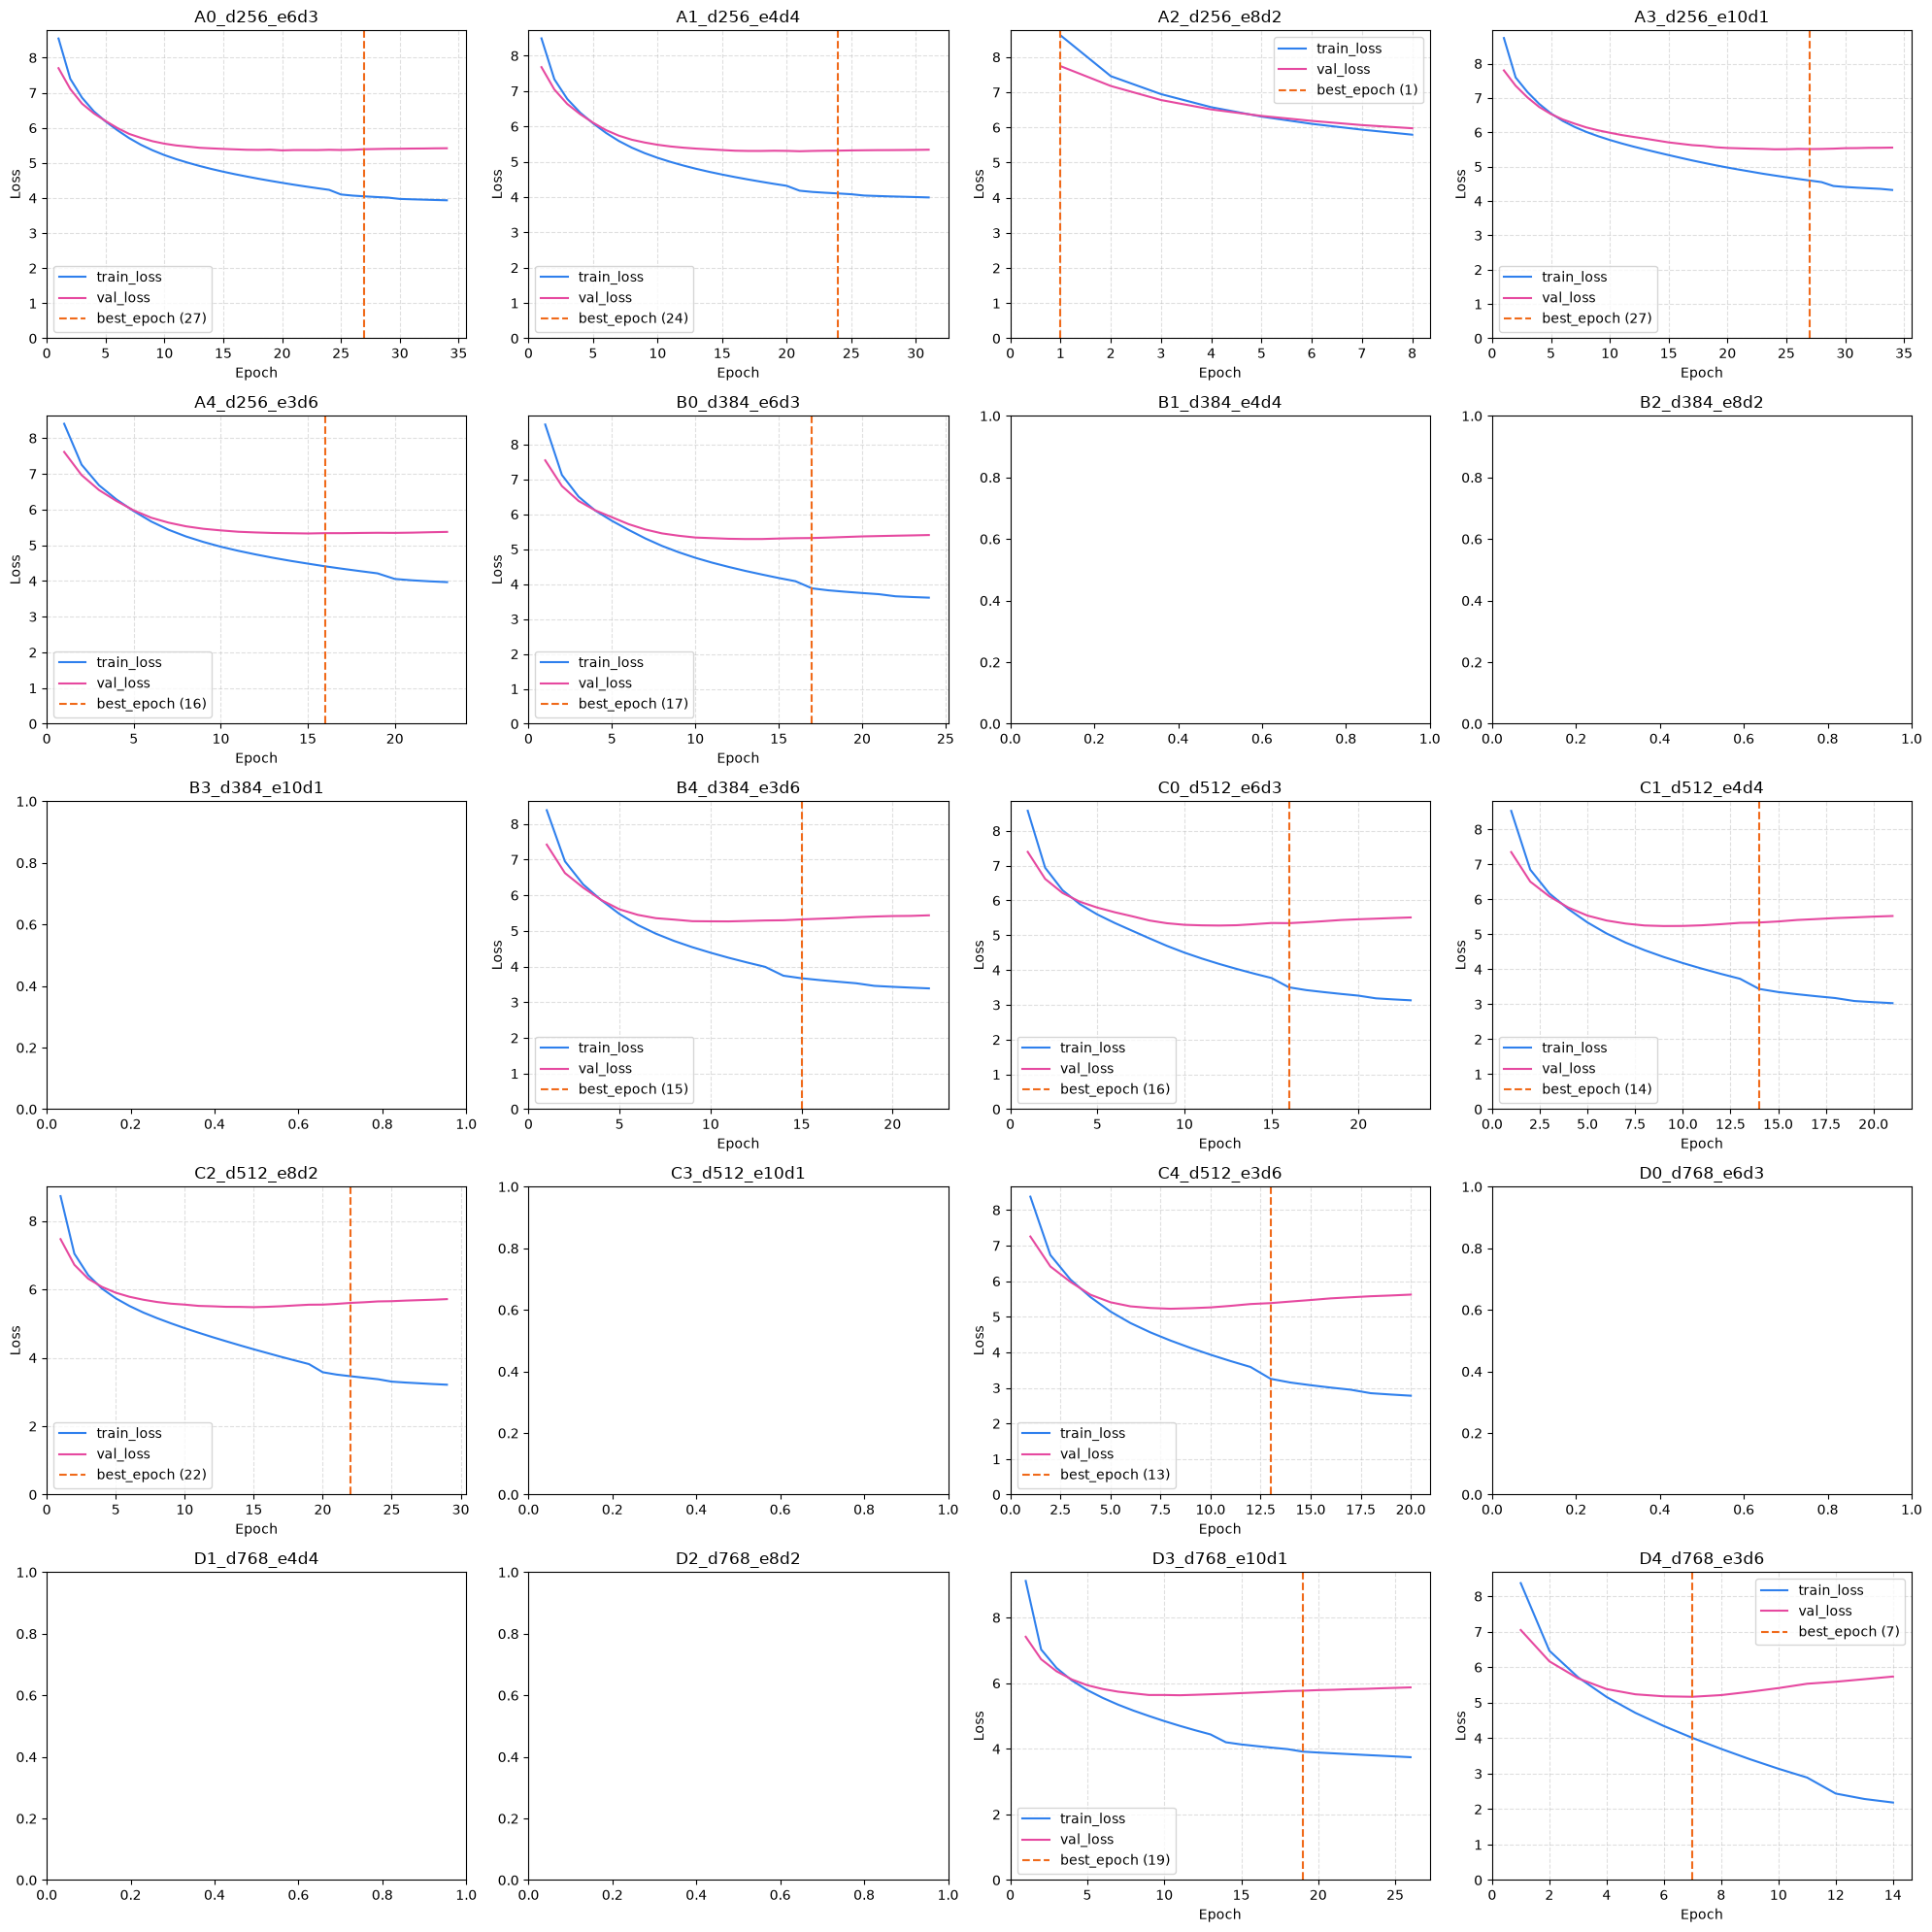

In [43]:
fig, ax = plt.subplots(5, 4, figsize=(20, 20))

arch_trials = sorted(study_arch.trials, key=lambda x: x.params["arch_key"])

for index, trial in enumerate(arch_trials):
    axis = ax[index // 4, index % 4]

    if trial.state.name == "PRUNED":
        axis.set_title(trial.params["arch_key"])
        continue

    plot_training_history_on_ax(
        axis,
        train_loss=trial.user_attrs["history"]["train_loss"],
        val_loss=trial.user_attrs["history"]["val_loss"],
        best_epoch=trial.user_attrs["best_epoch"],
        title=trial.params["arch_key"],
    )

plt.tight_layout()
plt.show()

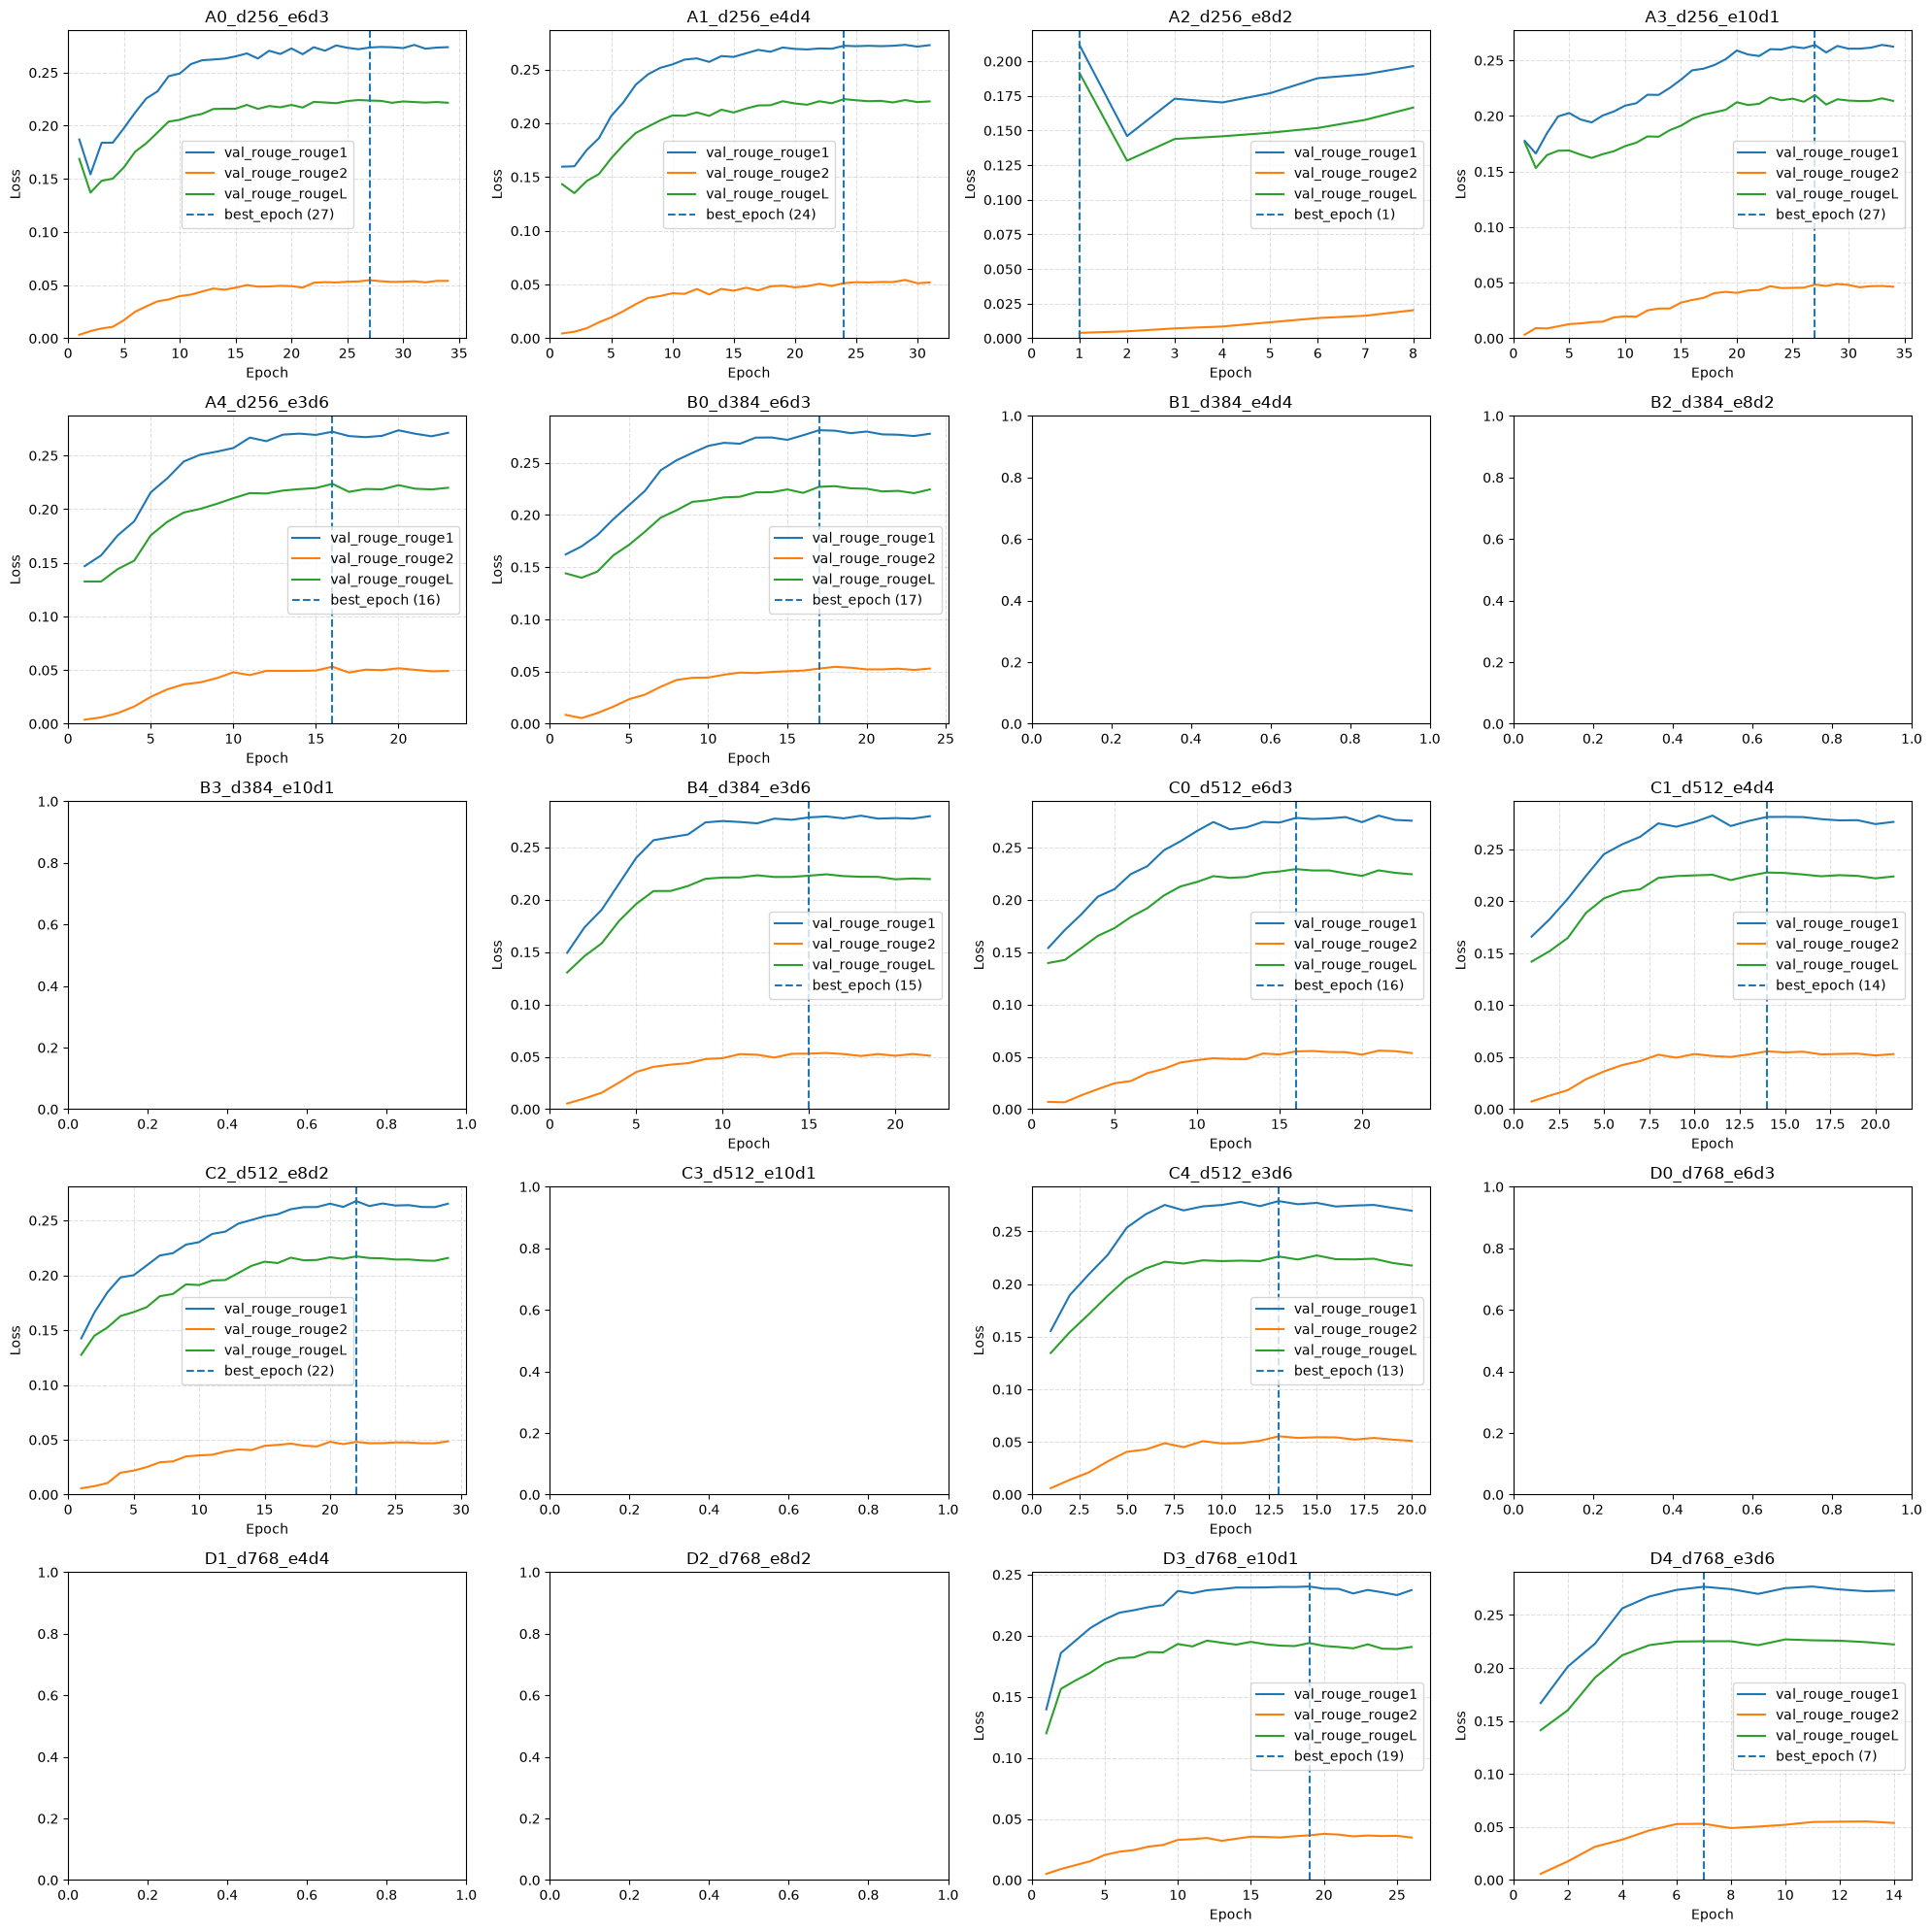

In [42]:
import numpy as np
import seaborn as sns

fig, ax = plt.subplots(5, 4, figsize=(20, 20))

arch_trials = sorted(study_arch.trials, key=lambda x: x.params["arch_key"])

for index, trial in enumerate(arch_trials):
    axis = ax[index // 4, index % 4]

    if trial.state.name == "PRUNED":
        axis.set_title(trial.params["arch_key"])
        continue

    trial_history = trial.user_attrs["history"]

    for metric_name in ("val_rouge_rouge1", "val_rouge_rouge2", "val_rouge_rougeL"):
        metric_data = trial_history[metric_name]

        epochs = np.arange(1, len(metric_data) + 1)
        sns.lineplot(x=epochs, y=metric_data, label=metric_name, ax=axis)

    best_epoch = trial.user_attrs["best_epoch"]
    if best_epoch is not None:
        axis.axvline(
            x=best_epoch,
            linestyle="--",
            linewidth=1.5,
            label=f"best_epoch ({best_epoch})",
        )

    axis.set_xlabel("Epoch")
    axis.set_ylabel("Loss")
    axis.set_xlim(left=0)
    axis.set_ylim(bottom=0)
    axis.set_title(trial.params["arch_key"])
    axis.legend()
    axis.grid(True, linestyle="--", alpha=0.4)


plt.tight_layout()
plt.show()

### Отбор шестёрки на 50%

Все 20 форм стейджа A, отсортированы по пику. `peak` — `max(intermediate_values)`,
а не `trial.value`: у спруненного трайла `value` хранит счёт эпохи прунинга, и по
нему `D1_d768_e4d4` (пик 0.1915 на эпохе 9, срез на 15-й с 0.1815) уходит на 11-е
место вместо первого. `Δ` — отставание от лучшего. `инф×` — относительная
стоимость генерации одного саммари, ∝ `dec_layers × dim²`, нормировано на `A0`:
энкодер в `generate` отрабатывает один раз, декодер — `max_length × beam_width`
раз, поэтому цену инференса задаёт только он.

| arch | peak | Δ | форма | M | мин/эп | инф× | | почему |
|------|------|---|-------|---|--------|------|---|--------|
| `D1_d768_e4d4` | 0.1915 | — | sym | 78.3 | 3.13 | 12.0 | ✅ | Лучший счёт стейджа, но спрунен и не подтверждён. Зонд «платит ли ширина дальше 512», снимается после A2 |
| `C0_d512_e6d3` | 0.1883 | 0.0032 | **enc>dec** | 39.6 | 2.65 | 4.0 | ✅ | Лидер среди адекватных форм. Опорная точка шортлиста |
| `C1_d512_e4d4` | 0.1882 | 0.0033 | sym | 37.6 | 2.10 | 5.3 | ✅ | Δ0.0001 к `C0` при −21% мин/эп и пике на 14-й вместо 21-й. Тест: покупает ли что-то 6-й слой энкодера |
| `B0_d384_e6d3` | 0.1876 | 0.0039 | **enc>dec** | 23.8 | 2.04 | 2.2 | ✅ | Та же форма вдвое дешевле `C0` при Δ0.0007. Якорь середины |
| `C4_d512_e3d6` | 0.1868 | 0.0047 | dec-heavy | 42.8 | 2.10 | 8.0 | ❌ | `C0` доминирует: +0.0015 при вдвое дешёвом инференсе |
| `D4_d768_e3d6` | 0.1859 | 0.0056 | dec-heavy | 90.1 | 3.00 | 18.0 | ❌ | Худший размен таблицы: 90.1M и 18× инференс за счёт ниже, чем у 23.8M `B0` |
| `B4_d384_e3d6` | 0.1856 | 0.0059 | dec-heavy | 25.6 | 1.91 | 4.5 | ❌ | `B0` доминирует: +0.0020 при вдвое дешёвом инференсе |
| `A0_d256_e6d3` | 0.1840 | 0.0075 | **enc>dec** | 12.0 | 1.62 | 1.0 | ✅ | Нижняя граница. Если на 50% не отстанет — все остальные просто дороже |
| `A4_d256_e3d6` | 0.1830 | 0.0085 | dec-heavy | 12.7 | 1.74 | 2.0 | ❌ | `A0` доминирует: +0.0010 при вдвое дешёвом инференсе |
| `A1_d256_e4d4` | 0.1829 | 0.0086 | sym | 11.4 | **1.48** | 1.3 | ✅ | Тот же тест `e6d3`/`e4d4`, что и пара `C0`/`C1`, на дешёвом конце. Самая дешёвая эпоха стейджа |
| `B1_d384_e4d4` | 0.1822 | 0.0093 | sym | 22.7 | 1.73 | 3.0 | ❌ | Пара к `B0`, но Δ0.0054 — против 0.0001 на 512 и 0.0011 на 256. Вопрос уже задан дважды дешевле |
| `C2_d512_e8d2` | 0.1777 | 0.0138 | enc>dec 4:1 | 41.7 | 3.21 | 2.7 | ❌ | Резкий перекос не работает: −0.0106 к `C0` при самой дорогой эпохе на своей ширине |
| `A3_d256_e10d1` | 0.1769 | 0.0146 | enc>dec 10:1 | 13.0 | 1.97 | **0.3** | ❌ | Самый дешёвый инференс в таблице, но Δ0.0146 — на порядок вне полосы шума |
| `D0_d768_e6d3` | 0.1694 | 0.0221 | **enc>dec** | 83.1 | 4.07 | 9.0 | ❌ | Единственный enc>dec на 768 — и он провалился. Поэтому 768 представлен симметричным `D1` |
| `D2_d768_e8d2` | 0.1601 | 0.0314 | enc>dec 4:1 | 87.8 | 4.93 | 6.0 | ❌ | Глубокий энкодер на большой ширине: дорого и плохо |
| `D3_d768_e10d1` | 0.1570 | 0.0345 | enc>dec 10:1 | 92.5 | 5.81 | 3.0 | ❌ | 110 минут до пика, худший счёт среди досчитанных |
| `A2_d256_e8d2` | 0.1358 | 0.0557 | enc>dec 4:1 | 12.5 | 1.75 | 0.7 | ❌ | Пик на эпохе 1 — артефакт, дальше только падал (0.1278 к 8-й). Реального пика нет |
| `C3_d512_e10d1` | 0.1290 | 0.0625 | enc>dec 10:1 | 43.8 | 3.80 | 1.3 | ❌ | Срезан на 5-й эпохе, Δ>0.06 |
| `B3_d384_e10d1` | 0.1279 | 0.0636 | enc>dec 10:1 | 26.2 | 2.80 | 0.8 | ❌ | Срезан на 5-й эпохе, Δ>0.06 |
| `B2_d384_e8d2` | 0.1264 | 0.0651 | enc>dec 4:1 | 25.0 | 2.40 | 1.5 | ❌ | Срезан на 5-й эпохе, Δ>0.06 |

Верхние десять лежат в 0.0086 друг от друга, дельты между соседями — 0.0001–0.0016.
Ранжирование по метрике внутри этой полосы ничего не решает, поэтому отбор идёт по
форме и стоимости, а метрика только очерчивает полосу.

Отказы делятся на четыре типа, и только один из них — по счёту.

* **Доминирование** (`C4`, `D4`, `B4`, `A4`) — четыре `e3d6`, по одному на ширину.
  Каждый проигрывает своему `e6d3` 0.0010–0.0056 и стоит на инференсе ровно вдвое
  дороже. Ни одного случая, где decoder-heavy окупился бы.
* **Дубль вопроса** (`B1`) — не проигрыш, а экономия: тест «6 слоёв энкодера против
  4» ставится на 256 и 512, третий раз на 384 не нужен.
* **Форма не работает** (`C2`, `A3`, `D2`, `D3`, `A2`, `C3`, `B3`, `B2`) — все восемь
  `e8d2` и `e10d1`, отставание 0.0138–0.0651. Вывод сильнее, чем «хуже»: enc>dec
  помогает в мягком варианте 2:1 и ломается на 4:1 и 10:1.
* **Ширина не вытянула свою форму** (`D0`) — единственный enc>dec на 768 упал до
  0.1694. Адекватной формы на этой ширине нет, и это сам по себе аргумент, что 768
  в шортлисте — временный слот.

Итог — не «шесть лучших», а сетка: `{256, 512} × {e6d3, e4d4}` (вопрос про глубину
энкодера, заданный дважды на разных ширинах), плюс `B0` якорем середины и `D1`
зондом верха.

Оговорка по `инф×`: это оценка по формуле, не замер. Attention по растущему
префиксу и по памяти энкодера масштабируется не как `dim²`, а на GPU мелкие модели
недогружают железо и выигрывают меньше, чем обещает арифметика. Порядок величины
верный, точное число — нет. Плюс сам поиск инференс не штрафует: валидационный
ROUGE считается по teacher-forced прогону, не через `generate`.

Что дальше — брать 6 архитектур разного размера, а не просто top-6 по счёту: **30% данных смещают ранжирование в пользу узких моделей**, и чистый топ рискует целиком оказаться внутри одного model_dim, поэтому отбирать лучших внутри каждой ширины (256 / 384 / 512 / 768). Для отобранных прогнать на 50% сразу две оси — сиды (разница между соседями в топе того же порядка, что и разброс по сидам) и ffn_ratio 2 против 4 (оптимальная глубина зависит от ratio, так что искать его после фиксации формы — значит недооценить глубокие-и-узкие варианты). Туда же просится use_weight_tying: 4.1M из 12.0M параметров.

## Stage A2 — the survivors at 50%

In [17]:
TOP_ARCH_GRID = {
    # model_dim = 256
    "A0_d256_e6d3": HParams(
        model_dim=256,
        num_heads=4,
        num_encoder_layers=6,
        num_decoder_layers=3,
        ffn_ratio=4,
    ),
    "A1_d256_e4d4": HParams(
        model_dim=256,
        num_heads=4,
        num_encoder_layers=4,
        num_decoder_layers=4,
        ffn_ratio=4,
    ),
    # model_dim = 384
    "B0_d384_e6d3": HParams(
        model_dim=384,
        num_heads=6,
        num_encoder_layers=6,
        num_decoder_layers=3,
        ffn_ratio=4,
    ),
    "B1_d384_e4d4": HParams(
        model_dim=384,
        num_heads=6,
        num_encoder_layers=4,
        num_decoder_layers=4,
        ffn_ratio=4,
    ),
    # model_dim = 512
    "C0_d512_e6d3": HParams(
        model_dim=512,
        num_heads=8,
        num_encoder_layers=6,
        num_decoder_layers=3,
        ffn_ratio=4,
    ),
    # model_dim = 768
    "D1_d768_e4d4": HParams(
        model_dim=768,
        num_heads=12,
        num_encoder_layers=4,
        num_decoder_layers=4,
        ffn_ratio=4,
    ),
}

NOISE_SEEDS = (42, 37, 23)

assert all(hp.is_valid for hp in TOP_ARCH_GRID.values()), "head count must divide dim"


pd.DataFrame(
    [
        {
            "key": key,
            **asdict(hp),
            "params": f"{hp.num_params / 1e6:.1f}M",
        }
        for key, hp in TOP_ARCH_GRID.items()
    ]
)

,key,model_dim,num_heads,num_encoder_layers,num_decoder_layers,ffn_ratio,dropout,lr,weight_decay,use_weight_tying,seed,params
0,A0_d256_e6d3,256,4,6,3,4,0.1,0.0002,0.01,True,42,12.0M
1,A1_d256_e4d4,256,4,4,4,4,0.1,0.0002,0.01,True,42,11.4M
2,B0_d384_e6d3,384,6,6,3,4,0.1,0.0002,0.01,True,42,23.8M
3,B1_d384_e4d4,384,6,4,4,4,0.1,0.0002,0.01,True,42,22.7M
4,C0_d512_e6d3,512,8,6,3,4,0.1,0.0002,0.01,True,42,39.6M
5,D1_d768_e4d4,768,12,4,4,4,0.1,0.0002,0.01,True,42,78.3M


In [ ]:
def suggest_arch_seed(trial: optuna.Trial) -> HParams:
    """Picks one architecture from the grid; every other field is fixed."""
    arch_key = trial.suggest_categorical("arch_key", list(TOP_ARCH_GRID))
    seed = trial.suggest_categorical("seeds", list(NOISE_SEEDS))

    return replace(TOP_ARCH_GRID[arch_key], seed=seed)


study_arch_seed_50 = run_stage(
    Stage(
        name="study_arch_seed_50_2",
        epochs=50,
        n_trials=len(TOP_ARCH_GRID) * len(NOISE_SEEDS),
        fraction=0.5,
        batch_size=8,
        effective_batch_size=32,
        amp="auto",
        es_patience=7,
        es_min_delta=1e-3,
        warmup_epochs=1.0,
        gap_threshold=0.8,
        use_scheduler=True,
        show_progress=True,
        save_models=False,
    ),
    suggest_arch_seed,
    sampler=optuna.samplers.GridSampler(
        {"arch_key": list(TOP_ARCH_GRID), "seeds": list(NOISE_SEEDS)}
    ),
    pruner=optuna.pruners.NopPruner(),
)

[I 2026-08-24 12:13:35,601] A new study created in RDB with name: study_arch_seed_50_2
epoch 31/50:  62%[============        ] 116901/188550 :: eta=51:06, status=early stopped, train_loss=3.899, val_loss=4.868, val_rouge_mean=0.2202, val_rouge_rouge1=0.3142, val_rouge_rouge2=0.0806, val_rouge_rougeL=0.2657
[I 2026-08-24 13:36:59,061] Trial 0 finished with value: 0.2215510532259941 and parameters: {'arch_key': 'A0_d256_e6d3', 'seeds': 37}. Best is trial 0 with value: 0.2215510532259941.
epoch 21/50:  42%[========            ] 79191/188550 :: eta=1:36:28, status=early stopped, train_loss=3.622, val_loss=4.954, val_rouge_mean=0.2099, val_rouge_rouge1=0.3059, val_rouge_rouge2=0.06852, val_rouge_rougeL=0.2552
[I 2026-08-24 14:46:50,826] Trial 1 finished with value: 0.20988238602876663 and parameters: {'arch_key': 'B0_d384_e6d3', 'seeds': 42}. Best is trial 0 with value: 0.2215510532259941.
epoch 21/50:  42%[========            ] 79191/188550 :: eta=1:36:32, status=early stopped, train_loss=


[study_arch_seed_50_2] best value: 0.2216
[study_arch_seed_50_2] best params: {'arch_key': 'A0_d256_e6d3', 'seeds': 37}


In [27]:
study_arch_seed_50.trials

[FrozenTrial(number=0, state=<TrialState.COMPLETE: 1>, values=[0.2215510532259941], datetime_start=datetime.datetime(2026, 8, 24, 12, 13, 35, 606063), datetime_complete=datetime.datetime(2026, 8, 24, 13, 36, 59, 49709), params={'arch_key': 'A0_d256_e6d3', 'seeds': 37}, user_attrs={'best_epoch': 29, 'history': {'train_loss': [7.591740777715754, 6.693538618549061, 6.234850931233438, 5.929443337513727, 5.67182970275665, 5.438507827610603, 5.252101944811307, 5.108006197398344, 4.990087003869981, 4.890141880814503, 4.800909001725296, 4.720868777647757, 4.648780033691448, 4.581380042408946, 4.518747502950516, 4.461664227643029, 4.406786437055028, 4.356345852752248, 4.308619001429356, 4.26311233115223, 4.221416105851393, 4.180564970445116, 4.143869804981059, 4.106804354027463, 4.073288768721124, 4.040584210127548, 4.010903069869305, 3.9802494649550844, 3.952087202187204, 3.925954205171197, 3.899210584871952], 'val_loss': [7.023838488129581, 6.478122688053756, 6.164721595572183, 5.926599163253

In [24]:
pd.DataFrame(
    [
        {
            "state": trial.state.name,
            "value": trial.value,
            "best_epoch": trial.user_attrs.get("best_epoch"),
            **trial.params,
        }
        for trial in study_arch_seed_50.trials
    ]
).sort_values("value", ascending=False)

,state,value,best_epoch,arch_key,seeds
0,COMPLETE,0.221551,29.0,A0_d256_e6d3,37
10,COMPLETE,0.215935,22.0,B0_d384_e6d3,37
14,COMPLETE,0.213392,29.0,A0_d256_e6d3,42
9,COMPLETE,0.212395,17.0,B1_d384_e4d4,42
3,COMPLETE,0.211604,19.0,B1_d384_e4d4,37
12,COMPLETE,0.210288,16.0,B1_d384_e4d4,23
1,COMPLETE,0.209882,21.0,B0_d384_e6d3,42
5,PRUNED,0.203815,NaN,A1_d256_e4d4,37
2,PRUNED,0.199602,NaN,B0_d384_e6d3,23
13,PRUNED,0.199187,NaN,A1_d256_e4d4,42


In [36]:
BEST_ARCH = HParams(
    model_dim=256,
    num_heads=4,
    num_encoder_layers=6,
    num_decoder_layers=3,
    ffn_ratio=4,
)

FFN_RATIO = (1, 2, 4)

assert BEST_ARCH.is_valid, "head count must divide dim"

In [39]:
def suggest_arch_params(trial: optuna.Trial) -> HParams:
    """Picks one architecture from the grid; every other field is fixed."""
    ffn_ratio = trial.suggest_categorical("ffn_ratio", [2, 3, 4, 6])

    lr = trial.suggest_float("lr", 1e-4, 1e-3, log=True)
    dropout = trial.suggest_float("dropout", 0.05, 0.30)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 3e-2, log=True)

    return replace(
        BEST_ARCH,
        lr=lr,
        dropout=dropout,
        weight_decay=weight_decay,
        ffn_ratio=ffn_ratio,
    )


study_arch_params = run_stage(
    Stage(
        name="study_arch_params",
        epochs=50,
        n_trials=25,
        fraction=0.5,
        batch_size=8,
        effective_batch_size=32,
        amp="auto",
        es_patience=7,
        es_min_delta=1e-3,
        warmup_epochs=1.0,
        gap_threshold=0.8,
        use_scheduler=True,
        show_progress=True,
        save_models=False,
    ),
    suggest_arch_params,
    sampler=optuna.samplers.TPESampler(seed=SEED, n_startup_trials=5),
    pruner=optuna.pruners.HyperbandPruner(
        min_resource=10, max_resource=50, reduction_factor=3
    ),
)

[I 2026-08-25 20:42:24,092] Using an existing study with name 'study_arch_params' instead of creating a new one.
epoch 10/50:  20%[====                ] 37710/188550 :: eta=1:47:20, train_loss=5.234, val_loss=5.399, val_rouge_mean=0.1641, val_rouge_rouge1=0.2467, val_rouge_rouge2=0.04004, val_rouge_rougeL=0.2054  
[I 2026-08-25 21:09:14,570] Trial 9 pruned. 
epoch 30/50:  60%[============        ] 113130/188550 :: eta=53:53, train_loss=4.342, val_loss=4.983, val_rouge_mean=0.1915, val_rouge_rouge1=0.2824, val_rouge_rouge2=0.05635, val_rouge_rougeL=0.2357   
[I 2026-08-25 22:30:05,804] Trial 10 pruned. 
epoch 28/50:  56%[===========         ] 105588/188550 :: eta=57:32, status=early stopped, train_loss=3.983, val_loss=5.022, val_rouge_mean=0.2046, val_rouge_rouge1=0.3016, val_rouge_rouge2=0.06452, val_rouge_rougeL=0.2478
[I 2026-08-25 23:43:20,732] Trial 11 finished with value: 0.20463201900323233 and parameters: {'ffn_ratio': 2, 'lr': 0.0001704126665435988, 'dropout': 0.057119572784992


[study_arch_params] best value: 0.2507
[study_arch_params] best params: {'ffn_ratio': 2, 'lr': 0.0003172904608005838, 'dropout': 0.1633755698176126, 'weight_decay': 0.0003195415509121281}


In [40]:
study_arch_params.trials

[FrozenTrial(number=0, state=<TrialState.COMPLETE: 1>, values=[0.21618340412775675], datetime_start=datetime.datetime(2026, 8, 25, 12, 59, 4, 489743), datetime_complete=datetime.datetime(2026, 8, 25, 14, 36, 13, 146630), params={'ffn_ratio': 3, 'lr': 0.0001432249371823026, 'dropout': 0.08899863008405066, 'weight_decay': 1.8198993697268208e-06}, user_attrs={'best_epoch': 37, 'history': {'train_loss': [7.747789628713825, 6.967731524976808, 6.510082729281575, 6.199055036538679, 5.953038712355667, 5.730997078583157, 5.537510196395079, 5.38115378230185, 5.254090660706898, 5.147160677901166, 5.0543098681500185, 4.9722819282442625, 4.897920558907902, 4.830081431660536, 4.766104556999878, 4.70838038935993, 4.651713070143818, 4.600329870463513, 4.550713934907083, 4.504234794022221, 4.46045195707468, 4.4175672418633765, 4.378313362389429, 4.33970386189199, 4.304233484177182, 4.2690719127886405, 4.236703603228499, 4.202661480189264, 4.172823185767104, 4.144249340936429, 4.115575608918619, 4.08838

In [41]:
pd.DataFrame(
    [
        {
            "state": trial.state.name,
            "value": trial.value,
            "best_epoch": trial.user_attrs.get("best_epoch"),
            **trial.params,
        }
        for trial in study_arch_params.trials
    ]
).sort_values("value", ascending=False)

,state,value,best_epoch,ffn_ratio,lr,dropout,weight_decay
28,COMPLETE,0.250721,50.0,2,0.000317,0.163376,0.000320
31,COMPLETE,0.239565,46.0,2,0.000453,0.179711,0.000106
26,COMPLETE,0.231178,34.0,3,0.000336,0.136979,0.000019
17,COMPLETE,0.225669,27.0,3,0.000362,0.096132,0.000024
23,COMPLETE,0.222957,25.0,3,0.000369,0.092561,0.000013
27,PRUNED,0.219295,NaN,3,0.000354,0.138619,0.000024
21,PRUNED,0.219066,NaN,3,0.000381,0.121256,0.000038
14,PRUNED,0.218682,NaN,3,0.000174,0.084950,0.002733
33,PRUNED,0.217614,NaN,2,0.000451,0.163516,0.000051
0,COMPLETE,0.216183,37.0,3,0.000143,0.088999,0.000002


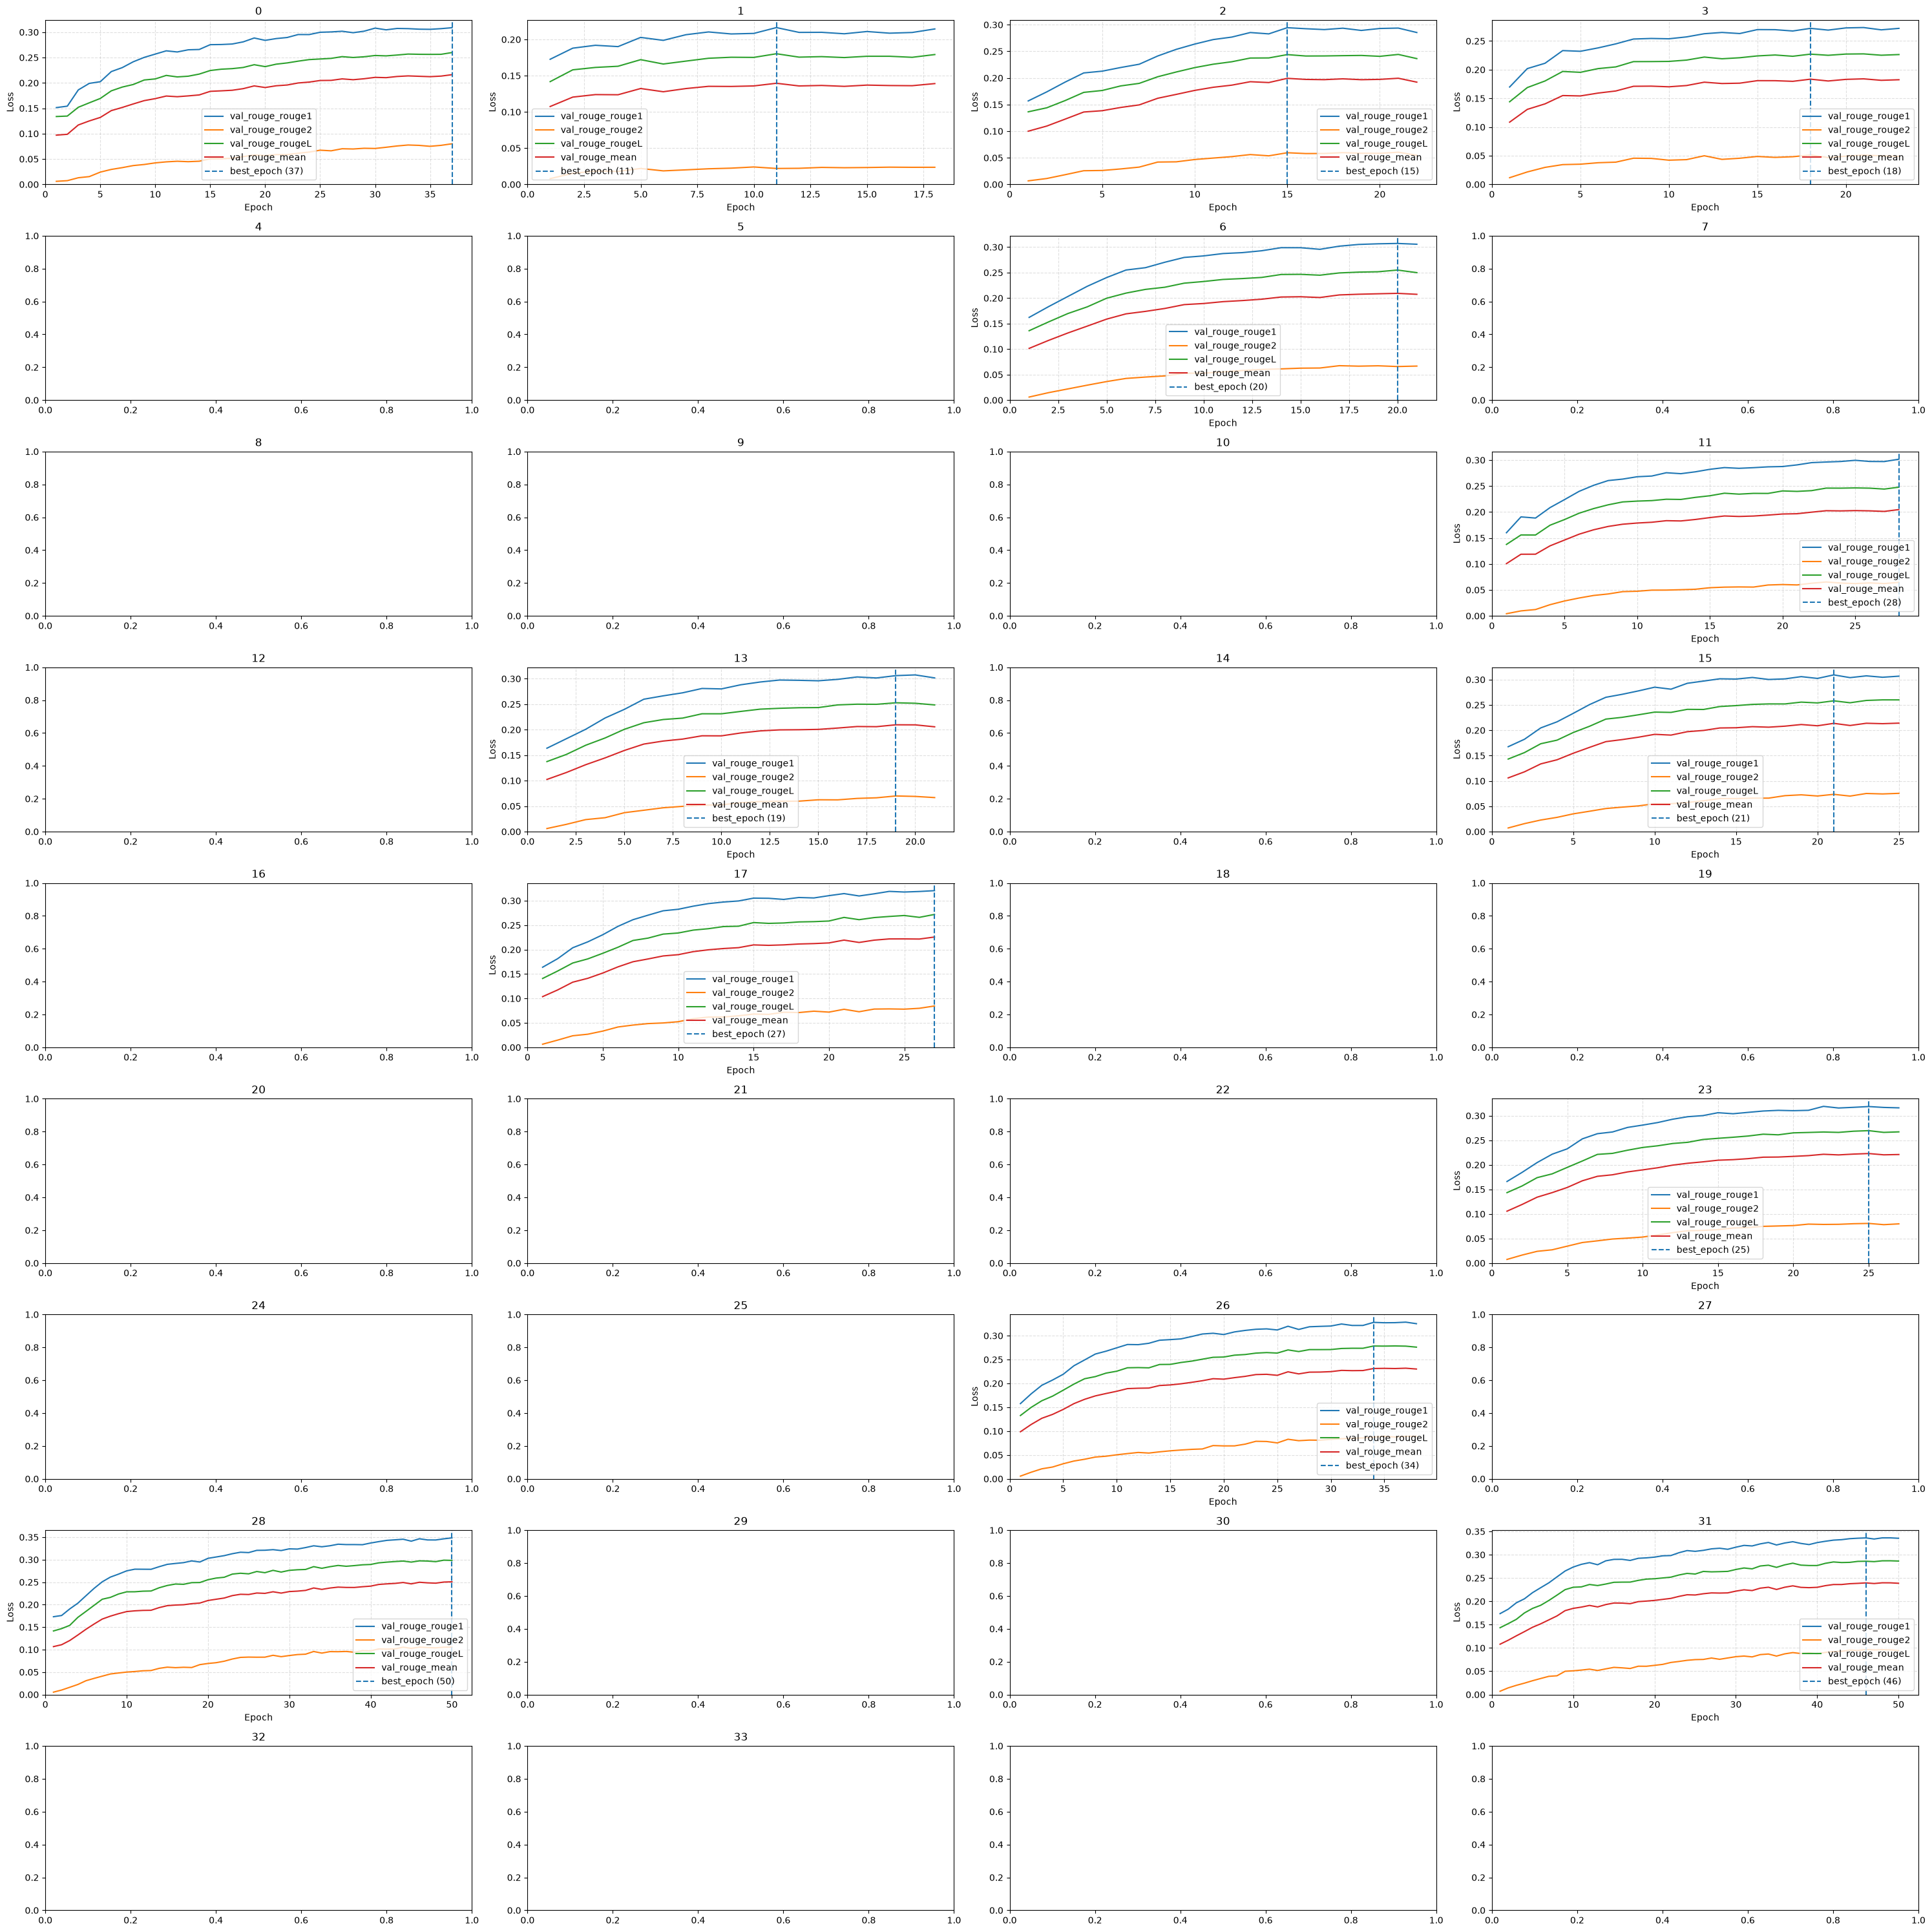

In [56]:
import numpy as np
import seaborn as sns

fig, ax = plt.subplots(9, 4, figsize=(30, 30))

for index, trial in enumerate(study_arch_params.trials):
    axis = ax[index // 4, index % 4]

    if trial.state.name != "COMPLETE":
        axis.set_title(str(trial.number))
        continue

    trial_history = trial.user_attrs["history"]

    for metric_name in (
        "val_rouge_rouge1",
        "val_rouge_rouge2",
        "val_rouge_rougeL",
        "val_rouge_mean",
    ):
        metric_data = trial_history[metric_name]

        epochs = np.arange(1, len(metric_data) + 1)
        sns.lineplot(x=epochs, y=metric_data, label=metric_name, ax=axis)

    best_epoch = trial.user_attrs["best_epoch"]
    if best_epoch is not None:
        axis.axvline(
            x=best_epoch,
            linestyle="--",
            linewidth=1.5,
            label=f"best_epoch ({best_epoch})",
        )

    axis.set_xlabel("Epoch")
    axis.set_ylabel("Loss")
    axis.set_xlim(left=0)
    axis.set_ylim(bottom=0)
    axis.set_title(str(trial.number))
    axis.legend()
    axis.grid(True, linestyle="--", alpha=0.4)


plt.tight_layout()
plt.show()

In [82]:
BEST_ARCH = HParams(
    model_dim=256,
    num_heads=4,
    num_encoder_layers=6,
    num_decoder_layers=3,
    ffn_ratio=2,
    lr=3.17e-4,
    weight_decay=3.2e-4,
    dropout=0.163,
)

NOISE_SEEDS = (23, 37, 42, 51, 73)

In [ ]:
def suggest_seed(trial: optuna.Trial) -> HParams:
    """Picks one architecture from the grid; every other field is fixed."""
    seed = trial.suggest_categorical("seeds", list(NOISE_SEEDS))

    return replace(BEST_ARCH, seed=seed)


study_final_seed_50 = run_stage(
    Stage(
        name="study_final_seed_50_2",
        epochs=80,
        n_trials=len(NOISE_SEEDS),
        fraction=0.5,
        batch_size=32,
        effective_batch_size=32,
        amp="auto",
        es_patience=7,
        es_min_delta=1e-3,
        warmup_epochs=1.0,
        gap_threshold=0.8,
        use_scheduler=True,
        show_progress=True,
        save_models=False,
    ),
    suggest_seed,
    sampler=optuna.samplers.GridSampler({"seeds": list(NOISE_SEEDS)}),
    pruner=optuna.pruners.NopPruner(),
)

[I 2026-08-27 14:08:36,725] Using an existing study with name 'study_final_seed_50_2' instead of creating a new one.



[study_final_seed_50_2] best value: 0.2705
[study_final_seed_50_2] best params: {'seeds': 73}


In [90]:
pd.DataFrame(
    [
        {
            "state": trial.state.name,
            "value": trial.value,
            "best_epoch": trial.user_attrs.get("best_epoch"),
            **trial.params,
        }
        for trial in study_final_seed_50.trials[:-3]
    ]
).sort_values("value", ascending=False)

,state,value,best_epoch,seeds
4,COMPLETE,0.270549,62,73
0,COMPLETE,0.263716,56,42
3,COMPLETE,0.263147,55,51
1,COMPLETE,0.256857,56,23
2,COMPLETE,0.233292,49,37


In [86]:
study_final_seed_50.trials

[FrozenTrial(number=0, state=<TrialState.COMPLETE: 1>, values=[0.2637155403693517], datetime_start=datetime.datetime(2026, 8, 27, 3, 53, 26, 316862), datetime_complete=datetime.datetime(2026, 8, 27, 5, 51, 48, 656961), params={'seeds': 42}, user_attrs={'best_epoch': 56, 'history': {'train_loss': [7.525758416446367, 6.583873810760883, 6.130338941591813, 5.843225657019943, 5.625087081145459, 5.429484214293259, 5.256696690516268, 5.120668640327149, 5.01352661551947, 4.925386277495166, 4.848424750879353, 4.780636265896602, 4.719484855917721, 4.662764144660287, 4.61157216631505, 4.563374564246387, 4.5178268810643525, 4.476991788543265, 4.436749666735435, 4.401115113385766, 4.3655586347148905, 4.333641282085711, 4.3048471303469755, 4.275597985185812, 4.247741059342015, 4.222708814034603, 4.198438506831601, 4.175260722462866, 4.153159792235571, 4.132880853835453, 4.111248668747502, 4.092198992380255, 4.074514041877348, 4.055635981085713, 4.03879755176875, 4.022114711672664, 4.004758142709728,

In [97]:
std = np.std(
    [
        np.mean(trial.user_attrs["history"]["val_rouge_mean"][-3:])
        for trial in study_final_seed_50.trials
        if trial.state.name == "COMPLETE"
    ]
)

print("std:", std, end=" ")

std: 0.013249191709647522 